# Linear Regression Baseline 모델
**대회**: Enefit – Predict Energy Behavior of Prosumers  
**평가지표**: MAE (Mean Absolute Error)  
**목표**: 프로슈머의 에너지 생산량 및 소비량 예측

---


## 목차
1. [라이브러리 임포트](#import)
2. [환경 설정](#environment)
3. [데이터 로드](#load)
4. [데이터 전처리](#preprocessing)
5. [모델 학습 및 평가](#model)
6. [결과 시각화](#visualization)
   - 6.1 실제값 vs 예측값
   - 6.2 시간 흐름 그래프
7. [특성 중요도 분석](#importance)

## Feature 구성 (Compact)

**입력 변수 (X)**
- `target`, `datetime`, `date`, `row_id` 제외한 모든 전처리 변수

**구성 요소**
- 과거값 (lag features)
- 시간 정보 (hour, weekday 등)
- 기상 데이터
- 외부 변수 (가격 등)
- 파생 통계값 (rolling 등)

<a id="import"></a>
## 1️ 라이브러리 임포트

필요한 라이브러리들을 임포트합니다.

In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

<a id="environment"></a>
## 2️ 환경 설정

GPU 및 CPU 환경을 설정합니다.

In [2]:
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

<a id="load"></a>
## 3️ 데이터 로드

전처리된 데이터를 불러옵니다.

In [3]:
DATA_PATH = "../data/processed_data/full_processed.csv"
df = pd.read_csv(DATA_PATH)

print("shape:", df.shape)
print(df.columns.tolist())
display(df.head())

shape: (2018352, 49)
['row_id', 'prediction_unit_id', 'county', 'is_business', 'product_type', 'is_consumption', 'target', 'datetime', 'date', 'hour', 'weekday', 'month', 'day', 'dayofyear', 'weekofyear', 'data_block_id', 'eic_count', 'installed_capacity', 'temperature', 'dewpoint', 'rain', 'snowfall', 'surface_pressure', 'cloudcover_total', 'windspeed_10m', 'shortwave_radiation', 'direct_solar_radiation', 'temp_county', 'solar_county', 'direct_solar', 'cloud_county', 'wind_county', 'euros_per_mwh', 'lowest_price_per_mwh', 'highest_price_per_mwh', 'lag_1', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168', 'rolling_std_168', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']


,row_id,prediction_unit_id,county,is_business,product_type,is_consumption,target,datetime,date,hour,...,rolling_mean_24,rolling_std_24,rolling_mean_168,rolling_std_168,hour_sin,hour_cos,month_sin,month_cos,dow_sin,dow_cos
0,0,0,0,0,1,0,0.713,2021-09-01 00:00:00,2021-09-01,0,...,274.644530,111.231530,273.831970,131.778150,0.000000,1.000000,-1.0,-1.836970e-16,0.974928,-0.222521
1,122,0,0,0,1,0,1.132,2021-09-01 01:00:00,2021-09-01,1,...,0.713000,111.231530,0.713000,131.778150,0.258819,0.965926,-1.0,-1.836970e-16,0.974928,-0.222521
2,244,0,0,0,1,0,0.490,2021-09-01 02:00:00,2021-09-01,2,...,0.922500,0.296278,0.922500,0.296278,0.500000,0.866025,-1.0,-1.836970e-16,0.974928,-0.222521
3,366,0,0,0,1,0,0.496,2021-09-01 03:00:00,2021-09-01,3,...,0.778333,0.325948,0.778333,0.325948,0.707107,0.707107,-1.0,-1.836970e-16,0.974928,-0.222521
4,488,0,0,0,1,0,0.149,2021-09-01 04:00:00,2021-09-01,4,...,0.707750,0.301258,0.707750,0.301258,0.866025,0.500000,-1.0,-1.836970e-16,0.974928,-0.222521


In [4]:
## datetime 처리
df["datetime"] = pd.to_datetime(df["datetime"])
df["date"] = pd.to_datetime(df["date"])

## 결측 확인
na_counts = df.isna().sum().sort_values(ascending=False)
print(na_counts.head(15))
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

row_id                0
prediction_unit_id    0
county                0
is_business           0
product_type          0
is_consumption        0
target                0
datetime              0
date                  0
hour                  0
weekday               0
month                 0
day                   0
dayofyear             0
weekofyear            0
dtype: int64


<a id="preprocessing"></a>
## 4️ 데이터 전처리

날짜 처리, 결측치 처리, 특성 및 대상 분리를 수행합니다.

In [5]:
drop_cols = ["target", "datetime", "date", "row_id"]  
X = df.drop(columns=drop_cols)
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())
display(y.head())

split_date = df["datetime"].quantile(0.8)

X_train = X[df["datetime"] < split_date]
y_train = y[df["datetime"] < split_date]

X_valid = X[df["datetime"] >= split_date]
y_valid = y[df["datetime"] >= split_date]

print("split_date:", split_date)
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

X shape: (2018352, 45)
y shape: (2018352,)


,prediction_unit_id,county,is_business,product_type,is_consumption,hour,weekday,month,day,dayofyear,...,rolling_mean_24,rolling_std_24,rolling_mean_168,rolling_std_168,hour_sin,hour_cos,month_sin,month_cos,dow_sin,dow_cos
0,0,0,0,1,0,0,2,9,1,244,...,274.644530,111.231530,273.831970,131.778150,0.000000,1.000000,-1.0,-1.836970e-16,0.974928,-0.222521
1,0,0,0,1,0,1,2,9,1,244,...,0.713000,111.231530,0.713000,131.778150,0.258819,0.965926,-1.0,-1.836970e-16,0.974928,-0.222521
2,0,0,0,1,0,2,2,9,1,244,...,0.922500,0.296278,0.922500,0.296278,0.500000,0.866025,-1.0,-1.836970e-16,0.974928,-0.222521
3,0,0,0,1,0,3,2,9,1,244,...,0.778333,0.325948,0.778333,0.325948,0.707107,0.707107,-1.0,-1.836970e-16,0.974928,-0.222521
4,0,0,0,1,0,4,2,9,1,244,...,0.707750,0.301258,0.707750,0.301258,0.866025,0.500000,-1.0,-1.836970e-16,0.974928,-0.222521


0    0.713
1    1.132
2    0.490
3    0.496
4    0.149
Name: target, dtype: float64

split_date: 2023-01-25 01:00:00
X_train: (1614612, 45)
X_valid: (403740, 45)


<a id="model"></a>
## 5️ 모델 학습 및 평가

Linear Regression 모델을 학습하고 검증 성능을 평가합니다.

In [6]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_valid)

lr_mae = mean_absolute_error(y_valid, lr_preds)
print("Linear Regression Validation MAE:", lr_mae)

from IPython.display import display

print("Linear Regression Result")
print(f"Validation MAE: {lr_mae:.4f}")

Linear Regression Validation MAE: 46.409792565013404
Linear Regression Result
Validation MAE: 46.4098


<a id="visualization"></a>
## 6️ 결과 시각화

### 6.1 실제값 vs 예측값

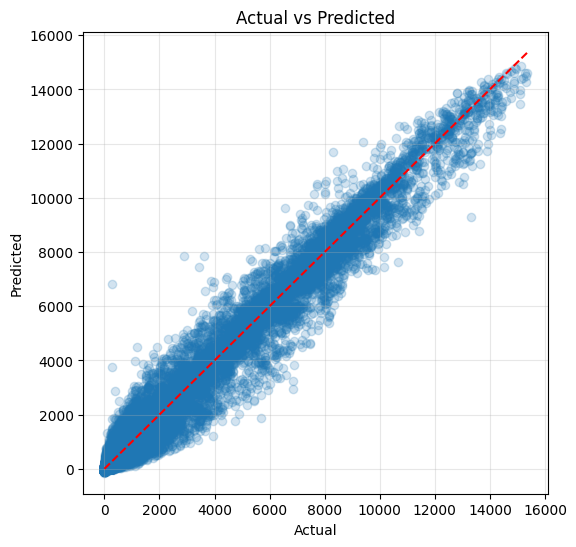

In [7]:
plt.figure(figsize=(6,6))
plt.scatter(y_valid, lr_preds, alpha=0.2)

# 대각선 추가 (완벽한 예측 기준선)
plt.plot(
    [y_valid.min(), y_valid.max()],
    [y_valid.min(), y_valid.max()],
    color='red', linestyle='--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(alpha=0.3)
plt.show()

### 6.2 시간 흐름 그래프

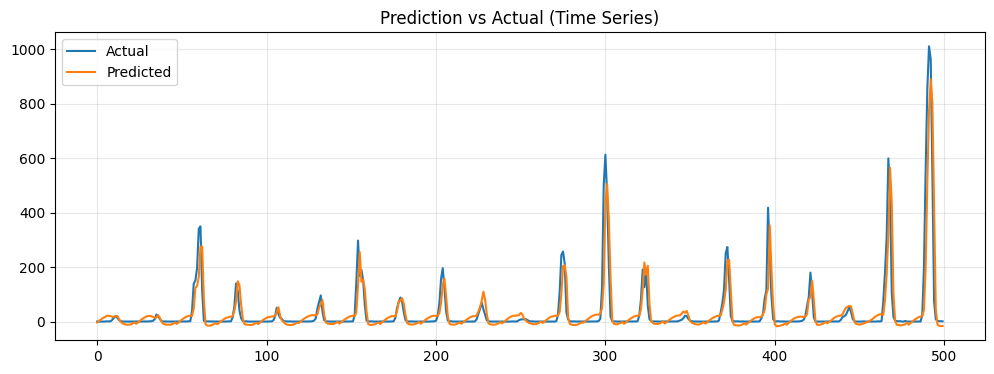

In [8]:
plt.figure(figsize=(12,4))
plt.plot(y_valid.values[:500], label="Actual")
plt.plot(lr_preds[:500], label="Predicted")

plt.legend()
plt.title("Prediction vs Actual (Time Series)")
plt.grid(alpha=0.3)
plt.show()

<a id="importance"></a>
## 7️ 특성 중요도 분석

모델의 계수(coefficient)를 기반으로 특성 중요도를 분석합니다.

In [9]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": lr_model.coef_
})

# 절댓값 기준 정렬 (중요!)
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print("Top 10 Important Features")
display(coef_df.head(10))

print("Least Important Features")
display(coef_df.tail(10))

Top 10 Important Features


,feature,coef,abs_coef
39,hour_sin,17.452989,17.452989
41,month_sin,-6.183306,6.183306
40,hour_cos,-5.318197,5.318197
42,month_cos,-4.941494,4.941494
16,rain,-4.031854,4.031854
14,temperature,-1.584272,1.584272
44,dow_cos,1.314955,1.314955
17,snowfall,1.105693,1.105693
15,dewpoint,1.051014,1.051014
43,dow_sin,-0.910909,0.910909


Least Important Features


,feature,coef,abs_coef
23,temp_county,0.005654,0.005654
35,rolling_mean_24,0.005191,0.005191
19,cloudcover_total,-0.003829,0.003829
0,prediction_unit_id,-0.003197,0.003197
33,lag_48,-0.001895,0.001895
18,surface_pressure,-0.001424,0.001424
1,county,0.001147,0.001147
12,eic_count,-0.001114,0.001114
13,installed_capacity,0.000635,0.000635
11,data_block_id,0.000613,0.000613
